<a href="https://colab.research.google.com/github/m1deey/Used_car_prediction/blob/main/02_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd
df=pd.read_csv("cleaned_car_data.csv")
df.head()

,milage,fuel_type,accident,clean_title,price,brand_Acura,brand_Alfa,brand_Aston,brand_Audi,brand_BMW,...,ext_col_Silver,ext_col_White,int_col_Black,int_col_Blue,int_col_Gray,int_col_Other,int_col_Red,int_col_Silver,int_col_White,model_age
0,51000,E85 Flex Fuel,At least 1 accident or damage reported,Yes,10300,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,11
1,34742,Gasoline,At least 1 accident or damage reported,Yes,38005,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,3
2,22372,Gasoline,None reported,Unknown,54598,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,2
3,88900,Hybrid,None reported,Yes,15500,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,9
4,9835,Gasoline,None reported,Unknown,34999,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,3


In [27]:
df = pd.get_dummies(df, columns=["fuel_type", "accident","clean_title"], dtype=int)

In [28]:
X=df.drop(columns="price",axis=1)

In [29]:
y=df["price"]

#LinearRegression

In [30]:
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
n = X_test.shape[0]
p = X_test.shape[1]

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Linear Regression Results")
print("-------------------------")
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")
print(f"Adj R² : {adj_r2:.4f}")

Linear Regression Results
-------------------------
MAE : 21324.54
RMSE: 138276.24
R²  : 0.0523
Adj R² : 1.6374


In [31]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)
lr_log = LinearRegression()
lr_log.fit(X_train_scaled, y_train_log)
pred_log = lr_log.predict(X_test_scaled)
pred = np.expm1(pred_log)
mae_log = mean_absolute_error(y_test_log, pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test_log, pred_log))
r2_log = r2_score(y_test_log, pred_log)
adj_r2_log = 1 - (1 - r2_log) * (n - 1) / (n - p - 1)

print("Y_log Results")
print("-------------------------")
print(f"MAE : {mae_log:.2f}")
print(f"RMSE: {rmse_log:.2f}")
print(f"R²  : {r2_log:.4f}")
print(f"Adj R² : {adj_r2_log:.4f}")

Y_log Results
-------------------------
MAE : 0.25
RMSE: 0.44
R²  : 0.7397
Adj R² : 1.1751


#Ridge

In [32]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV
ridge = Ridge()
y_train = np.log1p(y_train)
y_test= np.log1p(y_test)
param_grid = {
    "alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

ridge_grid.fit(X_train_scaled, y_train)

best_ridge = ridge_grid.best_estimator_
ridge_pred = best_ridge.predict(X_test_scaled)

mae = mean_absolute_error(y_test, ridge_pred)
rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression")
print("-------------------------")
print("Best Alpha:", ridge_grid.best_params_)
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

Ridge Regression
-------------------------
Best Alpha: {'alpha': 100}
MAE : 0.24
RMSE: 0.43
R²  : 0.7558


#Lasso

In [33]:
lasso = Lasso(max_iter=10000)

param_grid = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

lasso_grid = GridSearchCV(
    lasso,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

lasso_grid.fit(X_train_scaled, y_train)

best_lasso = lasso_grid.best_estimator_
lasso_pred = best_lasso.predict(X_test_scaled)

mae = mean_absolute_error(y_test, lasso_pred)
rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
r2 = r2_score(y_test, lasso_pred)

print("Lasso Regression")
print("-------------------------")
print("Best Alpha:", lasso_grid.best_params_)
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

Lasso Regression
-------------------------
Best Alpha: {'alpha': 0.001}
MAE : 0.22
RMSE: 0.41
R²  : 0.7834


Features importance

In [34]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": best_lasso.coef_
})

importance["Absolute"] = importance["Coefficient"].abs()

importance = importance.sort_values("Absolute", ascending=False)

importance.head(20)

,Feature,Coefficient,Absolute
1979,model_age,-0.357764,0.357764
0,milage,-0.263657,0.263657
1957,engine_size,0.130059,0.130059
44,brand_Porsche,0.120714,0.120714
26,brand_Lamborghini,0.116606,0.116606
1956,horsepower,0.098926,0.098926
14,brand_Ferrari,0.071995,0.071995
6,brand_Bentley,0.058869,0.058869
843,model_GT-R Premium,0.054341,0.054341
20,brand_Hyundai,-0.053180,0.053180


#RandomForest

In [35]:
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(random_state=42)

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_rf = random_search.best_estimator_

rf_pred = best_rf.predict(X_test)

mae = mean_absolute_error(y_test, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("-------------------------")
print("Best Parameters:", random_search.best_params_)
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

Random Forest Results
-------------------------
Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
MAE : 0.25
RMSE: 0.42
R²  : 0.7667


#XGBRegressor

In [36]:
from xgboost import XGBRegressor


xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 7, 10],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_xgb = random_search.best_estimator_

xgb_pred = best_xgb.predict(X_test)

mae = mean_absolute_error(y_test, xgb_pred)
rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
r2 = r2_score(y_test, xgb_pred)

print("XGBoost Results")
print("-------------------------")
print("Best Parameters:", random_search.best_params_)
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

XGBoost Results
-------------------------
Best Parameters: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
MAE : 0.20
RMSE: 0.35
R²  : 0.8384


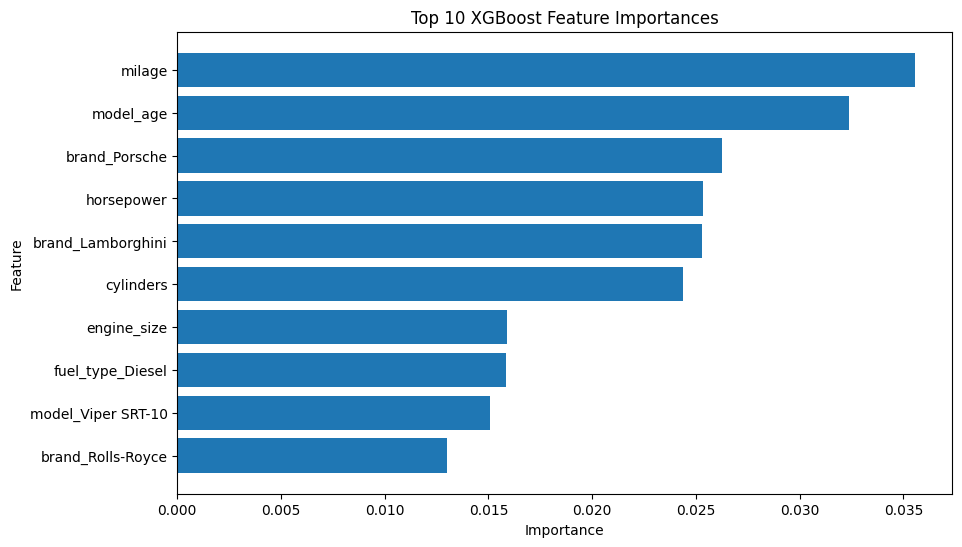

In [38]:

import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_xgb.feature_importances_
})

importance = importance.sort_values("Importance", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(importance["Feature"], importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Millage has the most coff for feature importance

## Model Comparison

- Linear Regression: Poor performance (R² = 0.05).
- Log Linear Regression: Much better after applying a log transformation (R² = 0.74).
- Ridge and Lasso: Similar performance with regularization.
- Random Forest: Strong performance (R² = 0.77).
- XGBoost: Best model (R² = 0.84).

**Conclusion:** XGBoost achieved the highest accuracy and was selected as the final model for predicting used car prices.

#(Actual vs Predicted)

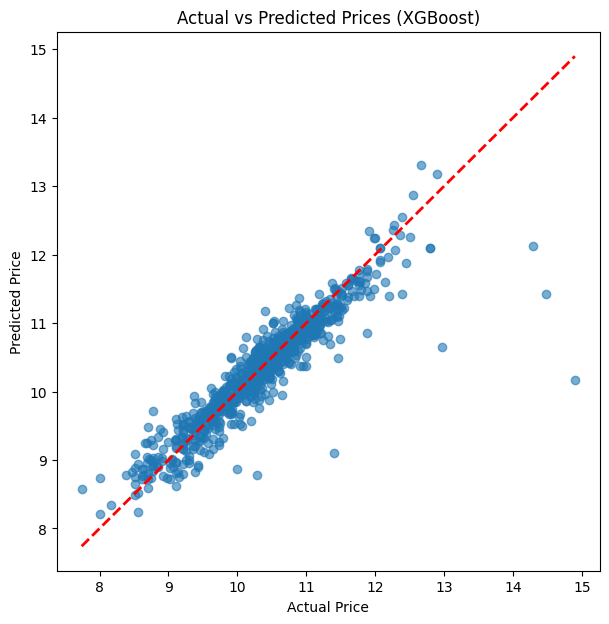

In [39]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, xgb_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Actual vs Predicted Prices (XGBoost)")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.show()

The Actual vs Predicted plot shows that most predictions lie close to the diagonal line, indicating that the XGBoost model predicts car prices accurately. A few outliers remain for high-priced vehicles, but the overall performance is strong with an R² score of approximately 0.84.